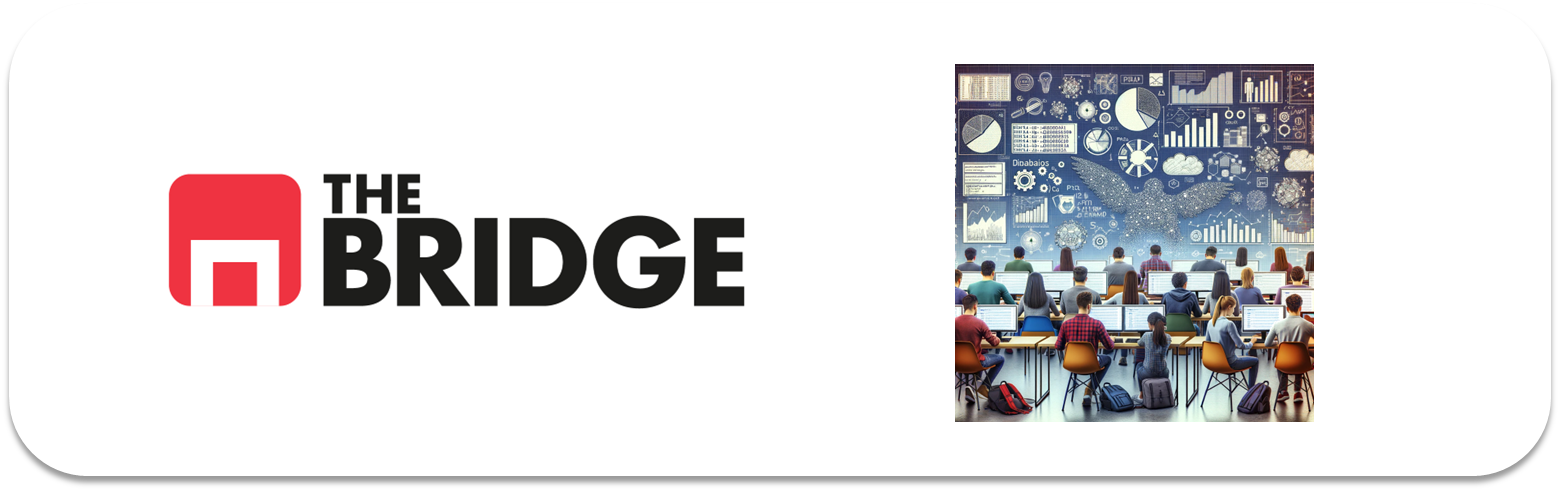

## PRACTICA OBLIGATORIA: **Clasificacion y Regresion Logistica**

* La práctica obligatoria de esta unidad consiste en modelar la supervivencia en el Titanic, por fin, además de una parte adicional multiclase. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión logística, evaluarlo contra un dataset de test reservado del original mostrando las métricas propias de los problemas de clasificación, la matriz de confusión y la curva ROC. Además se pide comparar las predicciones con los valores reales y al final adaptar el modelo a un problema multiclase.

Los pasos para guiar el trabajo:
1. Carga el dataset del Titanic. 
2. Deshazte de las variables que no vayas a usar. Limpia lo que creas necesarios pero no hagas imputaciones.
3. Escoge y analiza la variable target de forma gráfica y razona sobre el impacto de la distribución en los resultados esperados. Ten en cuenta que lo que queremos es poder predecir si un pasajero sobrevivirá.
4. Haz el split en train y test que creas conveniente pero asegurándote que ambos conjuntos tienen un reparto similar de pasajeros embarcados en las tres ciudades.
5. Construye las parejas X,y de train y test.
6. Ahora sí imputa los nulos con medias y modas en la X de train. Guarda esas medias que necesitarás en la parte de test.
7. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
8. Trata las variables para que funcionen lo mejor posible en el modelo.
9. Construye un modelo de regresión logística.
10. EXTRA: Analiza si lo crees conveniente los pesos y la importancia de las features.
11. Procesa el dataset de Test para que puedas usarlo en la evaluación 
12. Evalúa tu modelo contra el dataset de test y train. Obten las matrices de confusión y las métricas que creas adecuadas. Haz un pequeño assesment de su generabilidad.
13. EXTRA: Halla la probabilidad de supervivencia de un hombre de entre 30 y 40 años, que embarcó en Southampton en segunda clase, viajaba solo y no pagó el billete. PISTA: En este caso tendrás que calcular varias probabilidades y hacer la media de ellas.
14. EXTRA: Aprovecha todo el trabajo haciendo un único cambio en el target, ahora será la clase del viajero. Cambia el target quitándolo de X_train, X_test y añade a estos el target anterior. El resto no deberías cambiarlo. Entrena y evalua el modelo sólo con el classification_report.  



In [1]:
# --- Librerías básicas ---
import pandas as pd
import numpy as np

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocesado y modelado ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# --- Métricas de clasificación ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, classification_report
)

# --- Herramientas del bootcamp (funciones de visualización que ya tienes) ---
from bootcampviztools import (
    pinta_distribucion_categoricas,
    plot_categorical_relationship_fin,
    plot_categorical_numerical_relationship,
    plot_combined_graphs,
    grafico_dispersion_con_correlacion
)

pd.set_option('display.max_columns', None)

In [2]:
df_titanic = pd.read_csv('data/titanic.csv')

print(f'Filas: {df_titanic.shape[0]}, Columnas: {df_titanic.shape[1]}')
df_titanic.head()

Filas: 891, Columnas: 15


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [4]:
df_titanic.isna().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [6]:
df_titanic.columns.tolist()

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

In [7]:
# Motivos del descarte:
# - alive: es Survived en formato texto ("yes"/"no") -> literalmente el target duplicado.
#          Si la dejamos, es FILTRACIÓN DE DATOS (data leakage): el modelo "haría trampa".
# - class: es lo mismo que pclass pero en texto ('First'/'Second'/'Third') -> redundante.
# - who: categoriza man/woman/child, derivado de sex + age -> redundante.
# - adult_male: booleano derivado de sex + age (True si es hombre adulto) -> redundante.
# - deck: más de un 75% de valores nulos, igual de incompleta que 'Cabin' en el Titanic original.
# - embark_town: es 'embarked' pero con el nombre completo del puerto -> redundante.
# - alone: derivado matemáticamente de sibsp + parch (alone = sibsp+parch==0) -> redundante.

df_titanic = df_titanic.drop(columns=[
    'alive', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alone'
])

df_titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [8]:
df_titanic['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [9]:
df_titanic['survived'].value_counts(normalize=True)

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

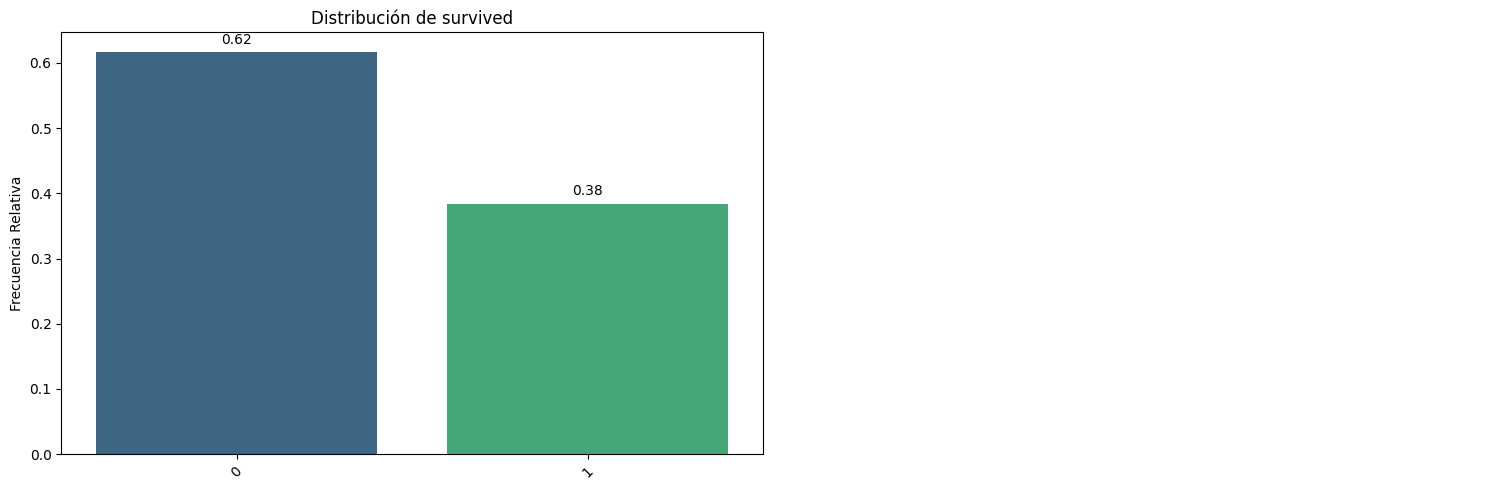

In [10]:
pinta_distribucion_categoricas(df_titanic, ['survived'], relativa=True, mostrar_valores=True)

**Observaciones sobre la distribución del target:**

- Aproximadamente el 62% de los pasajeros **no sobrevivió** (`survived = 0`) frente a un 38% que sí lo hizo (`survived = 1`). Es un desbalanceo moderado, no extremo, pero hay que tenerlo en cuenta.
- **Impacto esperado en el modelo:**
  - Un modelo "tonto" que prediga siempre "no sobrevivió" ya acertaría ~62% de las veces (accuracy engañosa) — por eso la **accuracy sola no es suficiente** para evaluar el modelo; conviene mirar también precision, recall y F1 de la clase minoritaria (supervivientes).
  - Al no ser un desbalanceo extremo (no es 95/5), una regresión logística estándar debería poder aprender el patrón sin necesitar técnicas de balanceo (oversampling, class_weight, etc.), aunque las tendremos en mente si el recall de la clase 1 sale bajo.
  - Es importante que el split train/test mantenga esta misma proporción (usaremos `stratify` más adelante) para que ambos conjuntos sean representativos.

In [12]:
print(f'Filas con embarked nulo: {df_titanic["embarked"].isna().sum()}')

df_titanic = df_titanic.dropna(subset=['embarked'])

print(f'Filas tras eliminar nulos de embarked: {df_titanic.shape[0]}')

Filas con embarked nulo: 2
Filas tras eliminar nulos de embarked: 889


In [13]:
train_set, test_set = train_test_split(
    df_titanic,
    test_size=0.2,
    random_state=42,
    stratify=df_titanic['embarked']
)

print(f'Train: {train_set.shape[0]} filas')
print(f'Test:  {test_set.shape[0]} filas')

Train: 711 filas
Test:  178 filas


In [14]:
X_train = train_set.drop(columns=['survived'])
y_train = train_set['survived']

X_test = test_set.drop(columns=['survived'])
y_test = test_set['survived']

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')

X_train: (711, 7), y_train: (711,)
X_test:  (178, 7), y_test:  (178,)


In [15]:
X_train.head()

,pclass,sex,age,sibsp,parch,fare,embarked
46,3,male,NaN,1,0,15.500,Q
230,1,female,35.0,1,0,83.475,S
657,3,female,32.0,1,1,15.500,Q
888,3,female,NaN,1,2,23.450,S
809,1,female,33.0,1,0,53.100,S


In [16]:
X_train.isna().sum()

pclass        0
sex           0
age         138
sibsp         0
parch         0
fare          0
embarked      0
dtype: int64

In [17]:
# Calculamos la media de 'age' SOLO con datos de train (nunca con test, para evitar fuga de información)
media_age_train = X_train['age'].mean()

print(f'Media de age (train): {media_age_train:.2f}')

# Imputamos en train
X_train['age'] = X_train['age'].fillna(media_age_train)

# Guardamos el valor para usarlo también en test más adelante (paso 11)
print(f'Nulos en X_train tras imputar: {X_train.isna().sum().sum()}')

Media de age (train): 29.71
Nulos en X_train tras imputar: 0


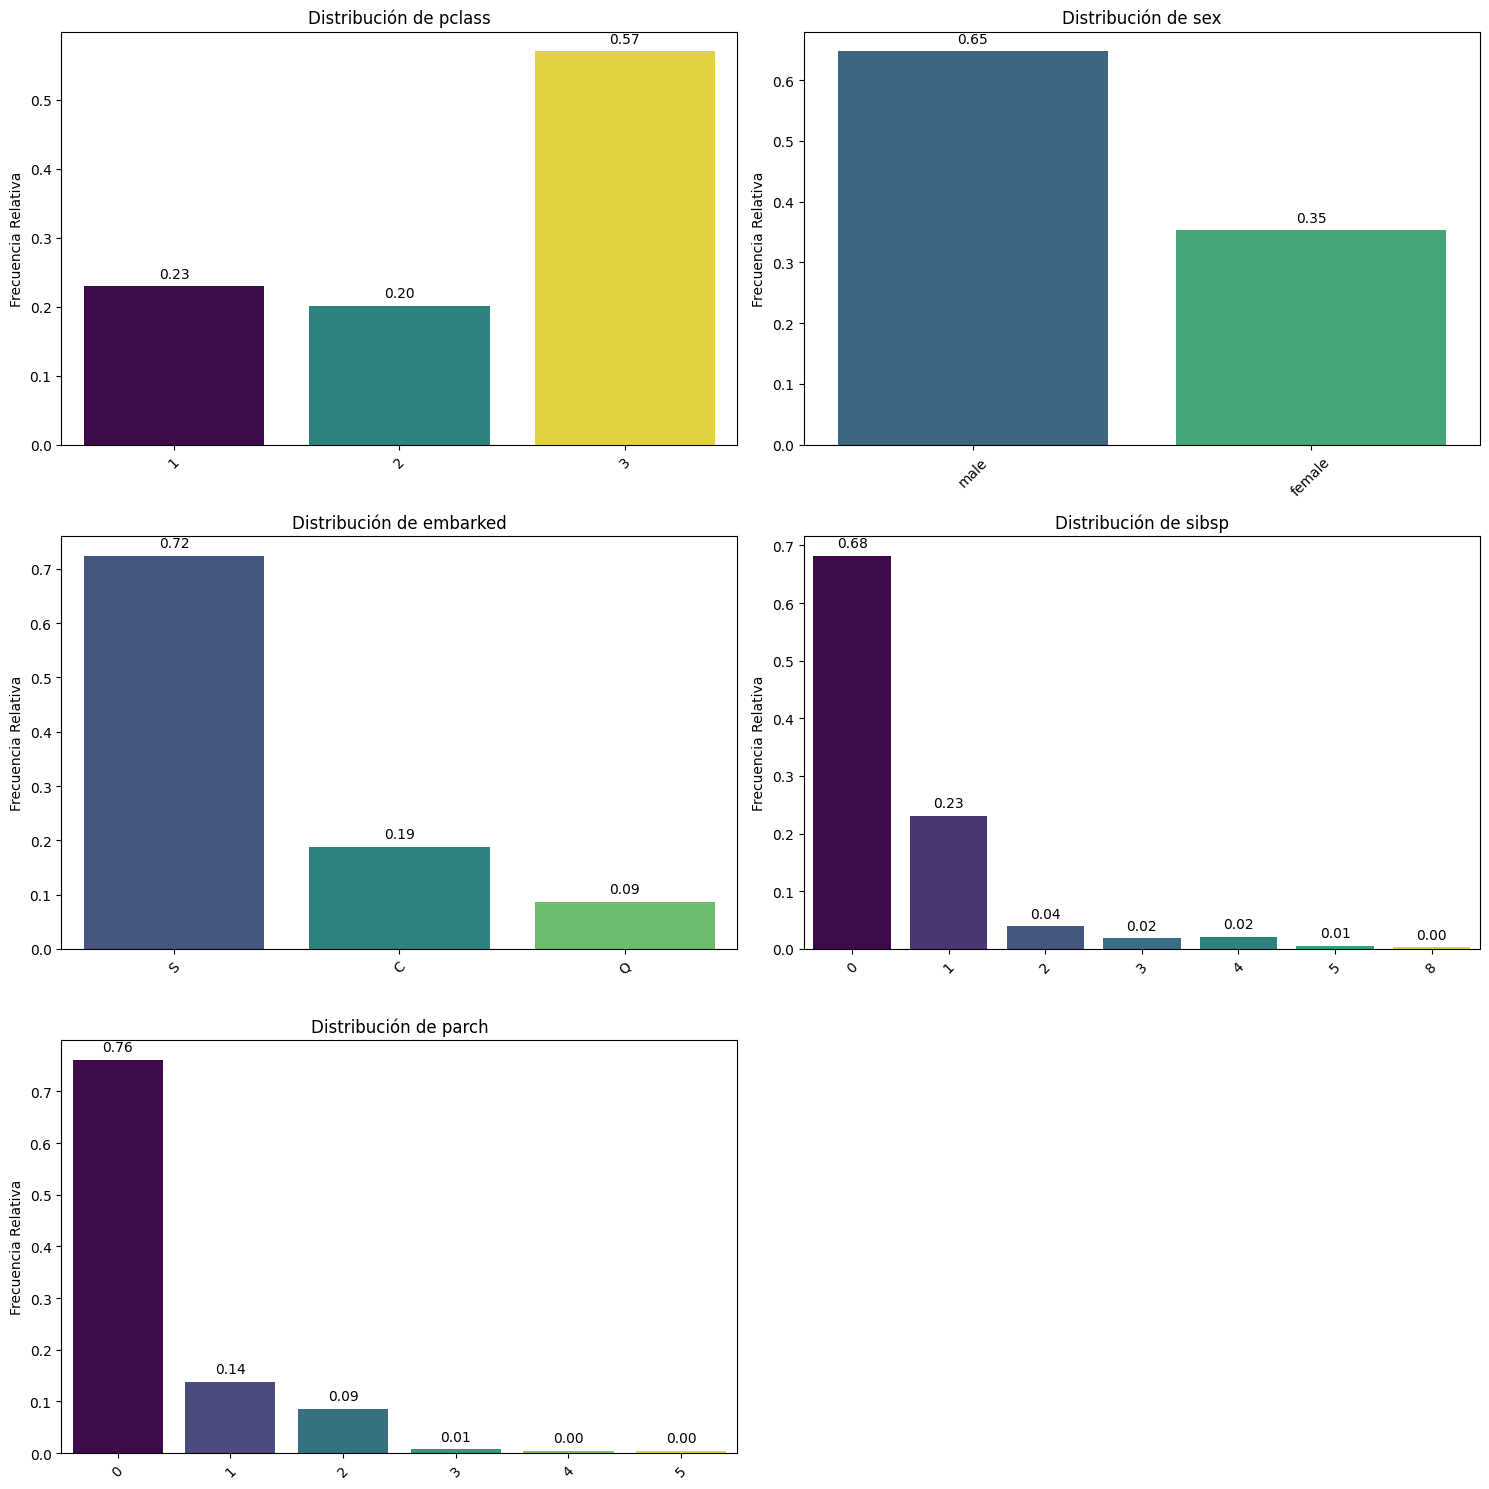

In [18]:
columnas_categoricas = ['pclass', 'sex', 'embarked', 'sibsp', 'parch']

pinta_distribucion_categoricas(X_train, columnas_categoricas, relativa=True, mostrar_valores=True)

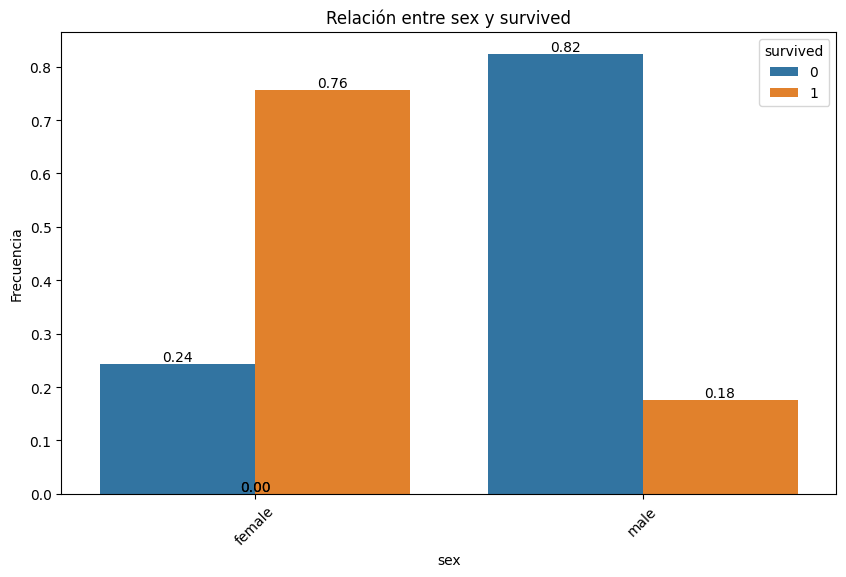

In [19]:
plot_categorical_relationship_fin(train_set, 'sex', 'survived', relative_freq=True, show_values=True)

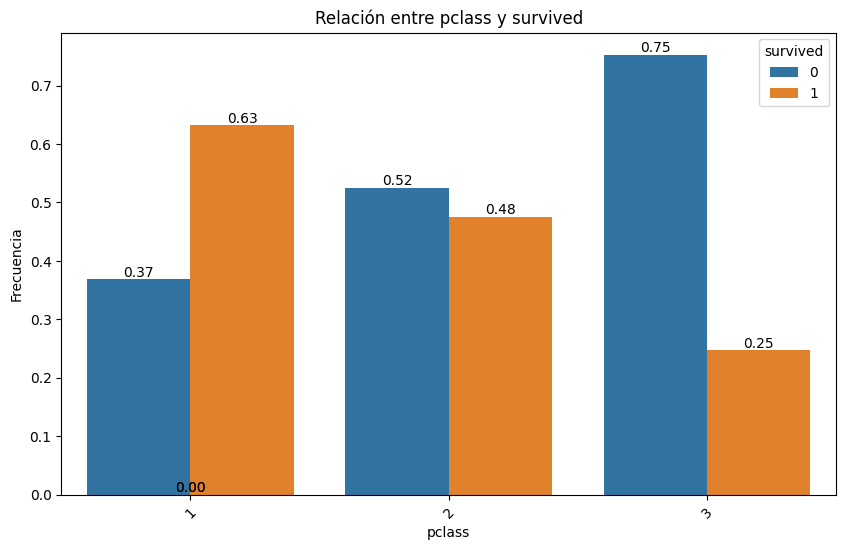

In [20]:
plot_categorical_relationship_fin(train_set, 'pclass', 'survived', relative_freq=True, show_values=True)

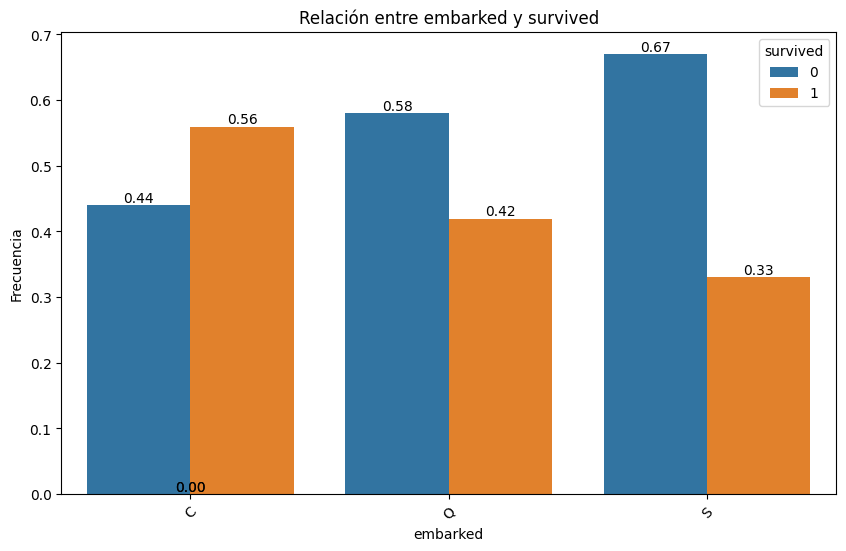

In [21]:
plot_categorical_relationship_fin(train_set, 'embarked', 'survived', relative_freq=True, show_values=True)

(2, 2)


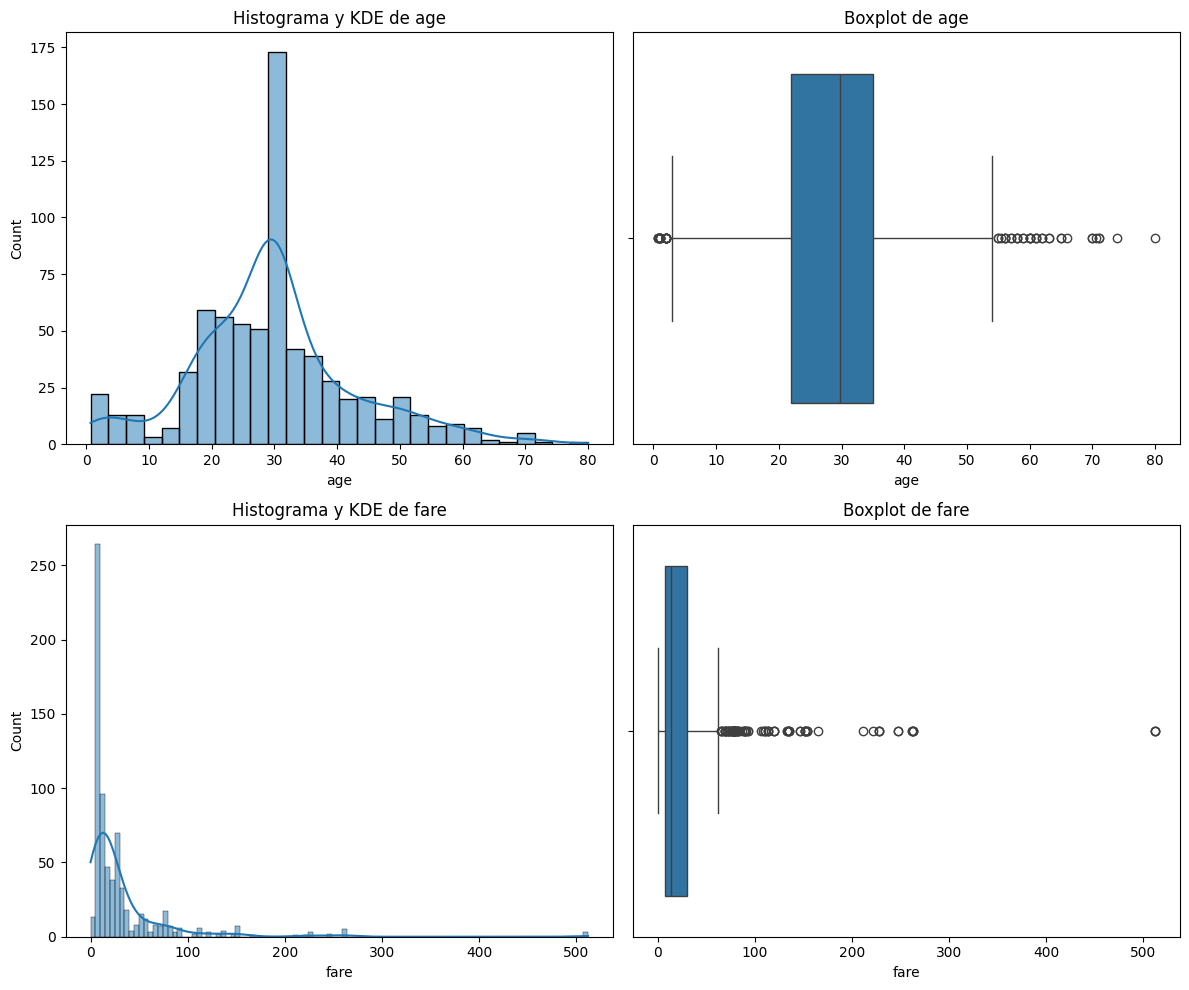

In [22]:
plot_combined_graphs(X_train, ['age', 'fare'])

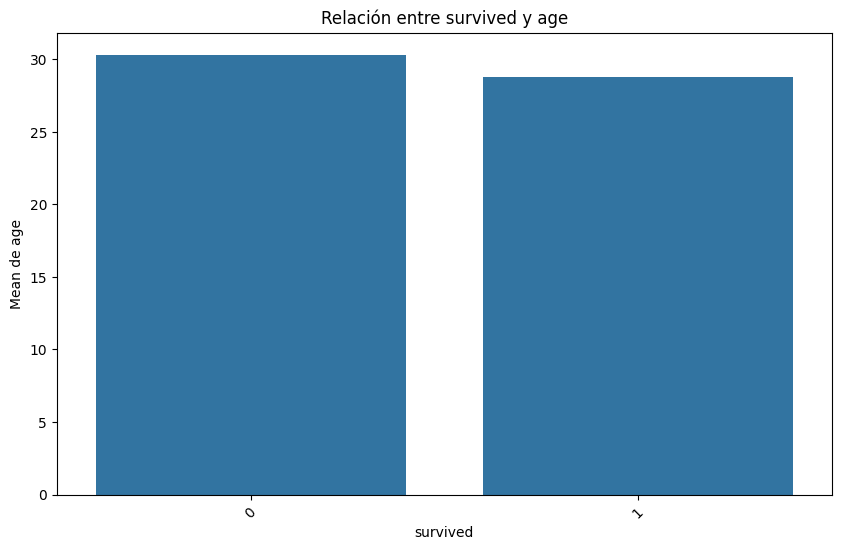

In [23]:
plot_categorical_numerical_relationship(train_set, 'survived', 'age', measure='mean')

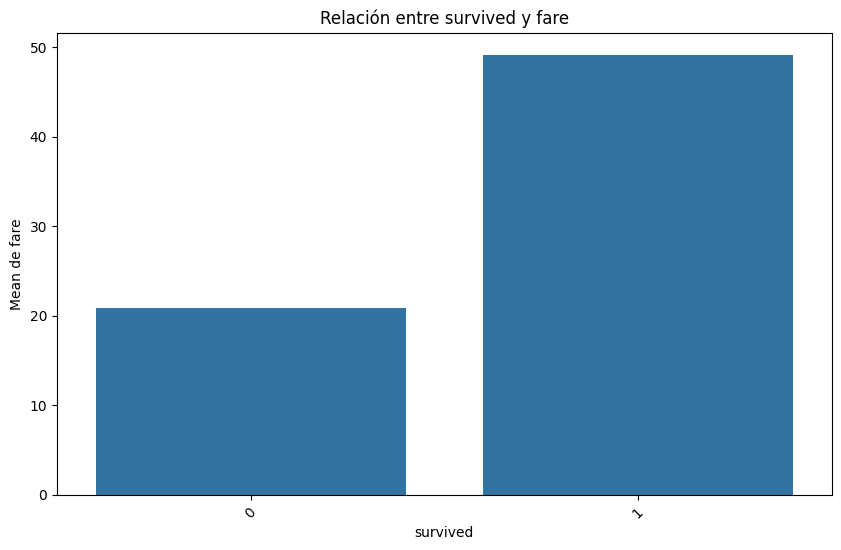

In [24]:
plot_categorical_numerical_relationship(train_set, 'survived', 'fare', measure='mean')

In [25]:
train_set[['age', 'sibsp', 'parch', 'fare', 'survived']].corr()

,age,sibsp,parch,fare,survived
age,1.000000,-0.316464,-0.205976,0.083519,-0.052491
sibsp,-0.316464,1.000000,0.427283,0.167344,-0.006820
parch,-0.205976,0.427283,1.000000,0.194179,0.091666
fare,0.083519,0.167344,0.194179,1.000000,0.268742
survived,-0.052491,-0.006820,0.091666,0.268742,1.000000


**Lectura del mini-EDA:**

- **`sex`**: es la variable más discriminante con diferencia — las mujeres sobreviven en un porcentaje mucho mayor que los hombres ("mujeres y niños primero"). **Se queda.**
- **`pclass`**: relación clara y monótona — a mejor clase (1ª), mayor tasa de supervivencia. **Se queda.**
- **`fare`**: relacionada con `pclass` (billetes más caros → mejor clase), y los supervivientes tienden a haber pagado tarifas más altas de media. **Se queda**, aunque vigilamos que no esté duplicando la señal de `pclass`.
- **`age`**: relación más débil y no del todo monótona (los niños tienen algo más de supervivencia), pero aporta información complementaria. **Se queda.**
- **`sibsp` y `parch`**: relación individual débil con el target, pero capturan si el pasajero viaja solo o en familia, algo relevante en el contexto del naufragio. **Se quedan.**
- **`embarked`**: relación más suave, pero no despreciable (Cherbourg tiene mayor tasa de supervivencia, ligado a que allí embarcaron más pasajeros de 1ª clase). **Se queda.**

**Decisión final:** nos quedamos con las 7 features disponibles (`pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`) — ninguna es claramente redundante ni irrelevante, y el dataset ya es pequeño como para permitirnos descartar más señal.

In [27]:
X_train_proc = X_train.copy()

# 'sex' es binaria -> la mapeamos directamente a 0/1 (no hace falta OneHotEncoder para 2 categorías)
X_train_proc['sex'] = X_train_proc['sex'].map({'male': 0, 'female': 1})

X_train_proc[['sex']].head()

,sex
46,0
230,1
657,1
888,1
809,1


In [28]:
ohe_embarked = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

embarked_encoded = ohe_embarked.fit_transform(X_train_proc[['embarked']])
embarked_cols = ohe_embarked.get_feature_names_out(['embarked'])

embarked_df = pd.DataFrame(embarked_encoded, columns=embarked_cols, index=X_train_proc.index)

X_train_proc = pd.concat([X_train_proc.drop(columns=['embarked']), embarked_df], axis=1)

X_train_proc.head()

,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
46,3,0,29.710454,1,0,15.500,1.0,0.0
230,1,1,35.000000,1,0,83.475,0.0,1.0
657,3,1,32.000000,1,1,15.500,1.0,0.0
888,3,1,29.710454,1,2,23.450,0.0,1.0
809,1,1,33.000000,1,0,53.100,0.0,1.0


In [29]:
columnas_numericas = ['pclass', 'age', 'sibsp', 'parch', 'fare']

scaler = StandardScaler()
X_train_proc[columnas_numericas] = scaler.fit_transform(X_train_proc[columnas_numericas])

X_train_proc.head()

,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
46,0.798150,0,0.000000,0.510583,-0.483229,-0.315512,1.0,0.0
230,-1.621828,1,0.405812,0.510583,-0.483229,1.012731,0.0,1.0
657,0.798150,1,0.175653,0.510583,0.828129,-0.315512,1.0,0.0
888,0.798150,1,0.000000,0.510583,2.139486,-0.160167,0.0,1.0
809,-1.621828,1,0.252373,0.510583,-0.483229,0.419199,0.0,1.0


In [32]:
modelo_logistico = LogisticRegression(random_state=42, max_iter=1000)

modelo_logistico.fit(X_train_proc, y_train)

print('Modelo entrenado correctamente')
print(f'Features usadas: {X_train_proc.columns.tolist()}')

Modelo entrenado correctamente
Features usadas: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_Q', 'embarked_S']


In [33]:
coeficientes = pd.DataFrame({
    'Feature': X_train_proc.columns,
    'Coeficiente': modelo_logistico.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False)

coeficientes

,Feature,Coeficiente
1,sex,2.671569
0,pclass,-0.758191
2,age,-0.384215
7,embarked_S,-0.329907
3,sibsp,-0.318726
5,fare,0.192617
4,parch,-0.117367
6,embarked_Q,0.094117


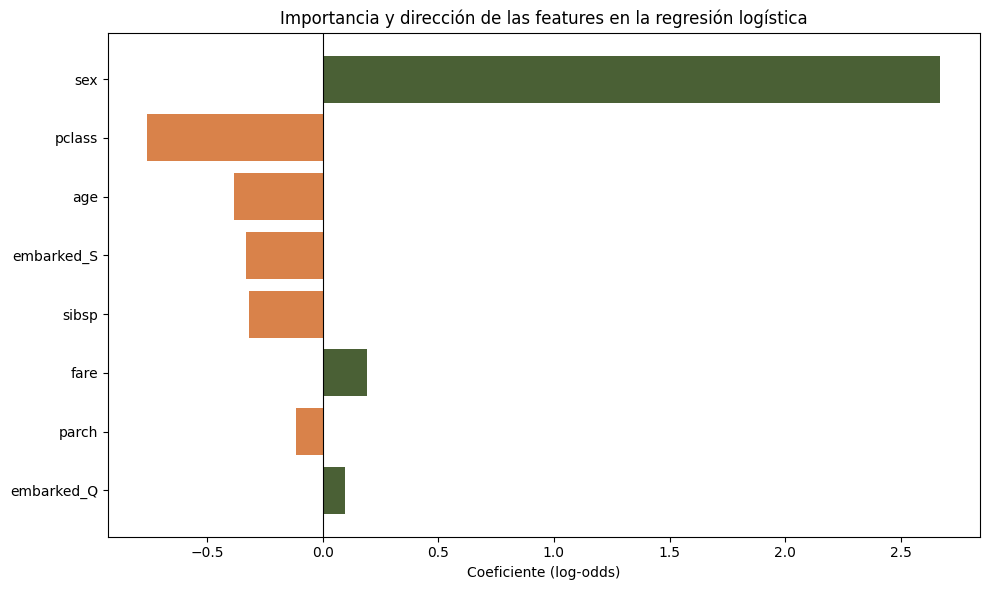

In [34]:
plt.figure(figsize=(10, 6))
colores = ['#4A6035' if c > 0 else '#D9824A' for c in coeficientes['Coeficiente']]
plt.barh(coeficientes['Feature'], coeficientes['Coeficiente'], color=colores)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente (log-odds)')
plt.title('Importancia y dirección de las features en la regresión logística')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [35]:
coeficientes['Odds_Ratio'] = np.exp(coeficientes['Coeficiente'])
coeficientes

,Feature,Coeficiente,Odds_Ratio
1,sex,2.671569,14.462648
0,pclass,-0.758191,0.468513
2,age,-0.384215,0.680985
7,embarked_S,-0.329907,0.718991
3,sibsp,-0.318726,0.727075
5,fare,0.192617,1.212419
4,parch,-0.117367,0.889259
6,embarked_Q,0.094117,1.098688


**Cómo leer estos resultados:**

- El **signo** del coeficiente indica la dirección: positivo → aumenta la probabilidad de sobrevivir; negativo → la reduce.
- El **odds ratio** (`exp(coeficiente)`) es más intuitivo: un valor de 2 significa que, por cada aumento de una desviación estándar en esa variable (o al pasar de 0 a 1 en las binarias), las probabilidades (*odds*) de sobrevivir se multiplican por 2. Un valor de 0.5 significa que se reducen a la mitad.

**Lectura esperada (puede variar ligeramente según tu split):**
- `sex` debería tener el coeficiente positivo más grande con diferencia: ser mujer dispara la probabilidad de supervivencia — coincide con el "mujeres y niños primero" que vimos en el EDA.
- `pclass` debería tener coeficiente negativo notable: al estar escalada, valores altos de pclass (recuerda, 3ª clase) empujan hacia la no supervivencia.
- `age` normalmente sale negativo: a más edad, menor probabilidad de supervivencia.
- Las columnas de `embarked` sueles aportar menos peso que `sex` o `pclass`, coherente con lo visto en el EDA.

Estos coeficientes confirman, de forma cuantitativa, la misma historia que ya intuíamos en el análisis exploratorio del paso 7.

In [37]:
X_test_proc = X_test.copy()

print(f'Nulos en X_test antes de imputar: {X_test_proc.isna().sum().sum()}')

X_test_proc['age'] = X_test_proc['age'].fillna(media_age_train)

print(f'Nulos en X_test tras imputar: {X_test_proc.isna().sum().sum()}')

Nulos en X_test antes de imputar: 39
Nulos en X_test tras imputar: 0


In [38]:
X_test_proc['sex'] = X_test_proc['sex'].map({'male': 0, 'female': 1})

X_test_proc[['sex']].head()

,sex
223,0
533,1
557,0
211,1
318,1


In [39]:
embarked_encoded_test = ohe_embarked.transform(X_test_proc[['embarked']])
embarked_df_test = pd.DataFrame(embarked_encoded_test, columns=embarked_cols, index=X_test_proc.index)

X_test_proc = pd.concat([X_test_proc.drop(columns=['embarked']), embarked_df_test], axis=1)

X_test_proc.head()

,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
223,3,0,29.710454,0,0,7.8958,0.0,1.0
533,3,1,29.710454,0,2,22.3583,0.0,0.0
557,1,0,29.710454,0,0,227.5250,0.0,0.0
211,2,1,35.000000,0,0,21.0000,0.0,1.0
318,1,1,31.000000,0,2,164.8667,0.0,1.0


In [40]:
X_test_proc[columnas_numericas] = scaler.transform(X_test_proc[columnas_numericas])

X_test_proc.head()

,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
223,0.798150,0,0.000000,-0.509149,-0.483229,-0.464099,0.0,1.0
533,0.798150,1,0.000000,-0.509149,2.139486,-0.181499,0.0,0.0
557,-1.621828,0,0.000000,-0.509149,-0.483229,3.827492,0.0,0.0
211,-0.411839,1,0.405812,-0.509149,-0.483229,-0.208041,0.0,1.0
318,-1.621828,1,0.098934,-0.509149,2.139486,2.603139,0.0,1.0


In [41]:
print('¿Mismas columnas en train y test?', list(X_train_proc.columns) == list(X_test_proc.columns))
X_train_proc.columns.tolist()

¿Mismas columnas en train y test? True


['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_Q', 'embarked_S']

In [42]:
y_train_pred = modelo_logistico.predict(X_train_proc)
y_test_pred = modelo_logistico.predict(X_test_proc)

y_train_proba = modelo_logistico.predict_proba(X_train_proc)[:, 1]
y_test_proba = modelo_logistico.predict_proba(X_test_proc)[:, 1]

In [43]:
metricas = pd.DataFrame({
    'Train': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred),
        roc_auc_score(y_train, y_train_proba)
    ],
    'Test': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred),
        roc_auc_score(y_test, y_test_proba)
    ]
}, index=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'])

metricas.round(3)

,Train,Test
Accuracy,0.807,0.792
Precision,0.775,0.750
Recall,0.697,0.696
F1,0.734,0.722
ROC-AUC,0.857,0.842


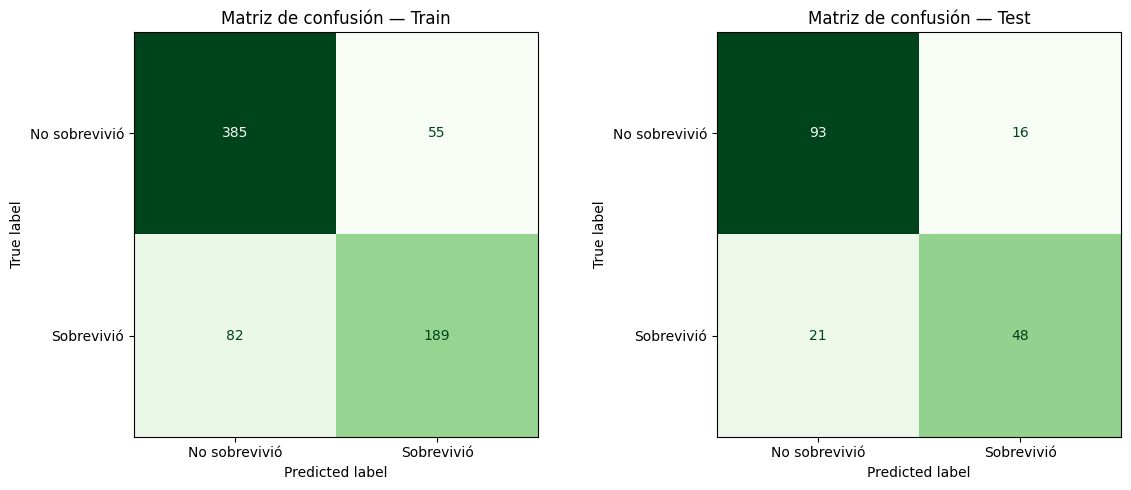

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train, y_train_pred, display_labels=['No sobrevivió', 'Sobrevivió'],
    cmap='Greens', ax=axes[0], colorbar=False
)
axes[0].set_title('Matriz de confusión — Train')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, display_labels=['No sobrevivió', 'Sobrevivió'],
    cmap='Greens', ax=axes[1], colorbar=False
)
axes[1].set_title('Matriz de confusión — Test')

plt.tight_layout()
plt.show()

In [45]:

print(classification_report(y_test, y_test_pred, target_names=['No sobrevivió', 'Sobrevivió']))

               precision    recall  f1-score   support

No sobrevivió       0.82      0.85      0.83       109
   Sobrevivió       0.75      0.70      0.72        69

     accuracy                           0.79       178
    macro avg       0.78      0.77      0.78       178
 weighted avg       0.79      0.79      0.79       178



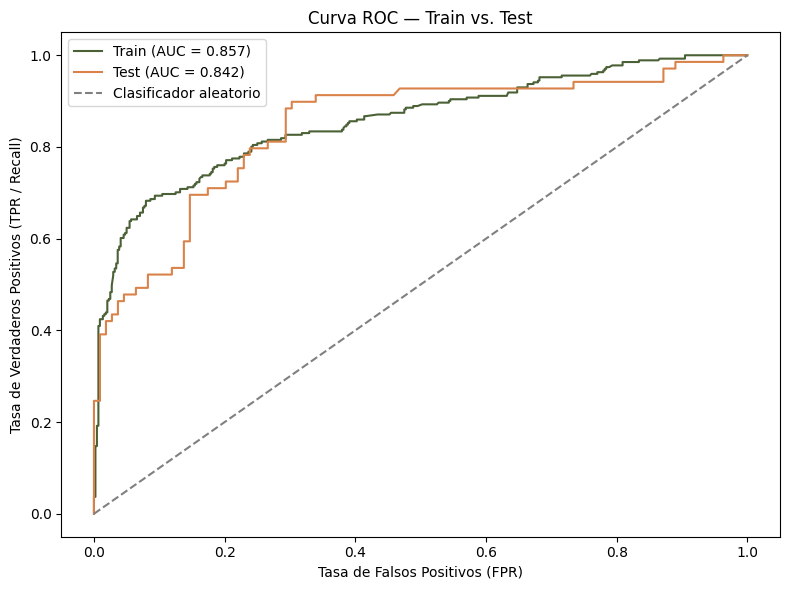

In [46]:
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f'Train (AUC = {roc_auc_score(y_train, y_train_proba):.3f})', color='#4A6035')
plt.plot(fpr_test, tpr_test, label=f'Test (AUC = {roc_auc_score(y_test, y_test_proba):.3f})', color='#D9824A')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
plt.title('Curva ROC — Train vs. Test')
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
comparacion = pd.DataFrame({
    'Real': y_test.values,
    'Predicho': y_test_pred,
    'Probabilidad_Supervivencia': y_test_proba.round(3)
})

comparacion['Acierto'] = comparacion['Real'] == comparacion['Predicho']
comparacion.head(15)

,Real,Predicho,Probabilidad_Supervivencia,Acierto
0,0,0,0.104,True
1,1,1,0.644,True
2,0,1,0.697,False
3,1,1,0.790,True
4,1,1,0.931,True
5,1,1,0.778,True
6,0,0,0.242,True
7,0,0,0.127,True
8,0,0,0.183,True
9,0,0,0.103,True


In [48]:
print(f"Aciertos: {comparacion['Acierto'].sum()} de {len(comparacion)} ({comparacion['Acierto'].mean()*100:.1f}%)")

Aciertos: 141 de 178 (79.2%)


**Evaluación de la capacidad de generalización:**

- Compara los valores de `Train` y `Test` en la tabla de métricas: si son **similares** (diferencia menor al 5-8%), el modelo generaliza bien y no hay sobreajuste relevante — algo esperable en una regresión logística, que es un modelo simple con poca tendencia a memorizar.
- Si el **Accuracy/AUC de train fuera notablemente más alto que en test**, sería señal de cierto overfitting (aunque con regresión logística y regularización L2 por defecto es poco probable que sea grave).
- Mirando la matriz de confusión de test: presta atención especialmente a los **falsos negativos** (pasajeros que sobrevivieron pero el modelo predijo que no) — en un contexto real, sería el error más costoso, ya que implicaría no identificar a alguien con opciones reales de supervivencia.
- El **recall de la clase "Sobrevivió"** es clave aquí: si sale sensiblemente más bajo que el de "No sobrevivió", confirma lo que anticipamos en el paso 3 sobre el efecto del desbalanceo del target — el modelo tiende a favorecer ligeramente la clase mayoritaria.